In [97]:
import pandas as pd
import os
import scanpy as sc
import cellflow

In [98]:
pred_dir = "/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_2"

In [99]:
files = os.listdir(pred_dir)

In [100]:
len(files)

86

In [101]:
pred_files = [el for el in files if ".h5ad" in el]

In [102]:
len(pred_files)

43

In [103]:
import json
with open("/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_2/adata_pred.json", "w") as f:
    json.dump(pred_files, f)



In [15]:
model_files = [el for el in files if ".pkl" in el]

In [16]:
len(model_files)

43

In [18]:
pred_file = "toasty-energy-49_0.01_all_preds.h5ad"

In [96]:
pred_file.strip("_all_preds.h5ad")+".csv"

'toasty-energy-49_0.01.csv'

In [19]:
adata_pred = sc.read_h5ad(os.path.join(pred_dir, pred_file))

/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [23]:
cytokine_held_out = "_".join(adata_pred.obs["condition"].values[0].split("_")[1:])

In [24]:
cytokine_held_out

'OX40L'

In [45]:
import anndata as ad
import pickle
from cellflow.preprocessing import transfer_labels, compute_wknn, centered_pca, project_pca, reconstruct_pca
from cellflow.metrics import compute_r_squared, compute_e_distance
import numpy as np

def compute_metrics(adata_ref: ad.AnnData, adata_pred_all_samples: ad.AnnData, donor_deg_dict: dict, adata_ood_true: ad.AnnData, n_neighbors: int=1, cell_type_col: str = "cell_type_new", min_cells_for_dist_metrics: int = 50) -> dict:
    dict_to_log = {}
    
    compute_wknn(ref_adata=adata_ref, query_adata=adata_pred_all_samples, n_neighbors=n_neighbors, ref_rep_key="X_pca", query_rep_key="X_pca_for_ct_transfer")
    transfer_labels(query_adata=adata_pred_all_samples, ref_adata=adata_ref, label_key=cell_type_col)
    
    ood_e_distances = []
    decoded_ood_r_squareds = []
    mean_decoded_r_sq_per_cell_types = []
    mean_e_distance_per_cell_types = []
    mean_deg_r_sq_per_cell_types = []

    for i in range(10):

        adata_pred = adata_pred_all_samples[adata_pred_all_samples.obs["sample"]==i]

        ood_e_distance = compute_e_distance(adata_ood_true.obsm["X_pca"], adata_pred.obsm["X_pca"])
        decoded_ood_r_squared = compute_r_squared(adata_ood_true.X.toarray(), adata_pred.layers["X_recon"])

        ood_e_distances.append(ood_e_distance)
        decoded_ood_r_squareds.append(decoded_ood_r_squared)
        

        r_sq = {}
        e_distance = {}
        deg_r_sq = {}
        
        for ct_cyto in donor_deg_dict.keys(): 
            cell_type = ct_cyto.split("_")[1]
            adata_true_ct = adata_ood_true[(adata_ood_true.obs[f"{cell_type_col}"]==cell_type)]
            adata_pred_ct = adata_pred[adata_pred.obs[f"{cell_type_col}_transfer"]==cell_type]
            if adata_pred_ct.n_obs == 0:
                continue
            dist_true_decoded = adata_true_ct.X.toarray()
            dist_pred_decoded = adata_pred_ct.X
            dist_true = adata_true_ct.obsm["X_pca"]
            dist_pred = adata_pred_ct.obsm["X_pca"]
            r_sq[f"decoded_r_squared_{cell_type}"] = compute_r_squared(dist_true_decoded, dist_pred_decoded)
            e_distance[f"e_distance_{cell_type}"] = compute_e_distance(dist_true, dist_pred)
            
            deg_mask = [True if el in donor_deg_dict[ct_cyto] else False for el in adata_ood_true.var_names]
            deg_true_decoded = adata_true_ct[:,deg_mask].X.toarray()
            deg_pred_decoded = adata_pred_ct[:,deg_mask].X
            deg_r_sq[f"deg_decoded_r_squared_{cell_type}"] = compute_r_squared(deg_true_decoded, deg_pred_decoded)

        mean_decoded_r_sq_per_cell_types.append(np.mean(list(r_sq.values())))
        mean_e_distance_per_cell_types.append(np.mean(list(e_distance.values())))
        mean_deg_r_sq_per_cell_types.append(np.mean(list(deg_r_sq.values())))

    # performance metrics to return
    for i in range(10):
        dict_to_log[f"ood_e_distance_{i}"] = ood_e_distances[i]
        dict_to_log[f"decoded_ood_r_squared_{i}"] = decoded_ood_r_squareds[i]
    dict_to_log["mean_ood_e_distance"] = np.mean(ood_e_distances)
    dict_to_log["mean_decoded_ood_r_squared"] = np.mean(decoded_ood_r_squareds)

    dict_to_log["mean_decoded_r_sq_per_cell_type"] = np.mean(mean_decoded_r_sq_per_cell_types)
    dict_to_log["mean_e_distance_per_cell_type"] = np.mean(mean_e_distance_per_cell_types)
    dict_to_log["mean_deg_r_sq_per_cell_type"] = np.mean(mean_deg_r_sq_per_cell_types)

    # now the uncertainty metrics

    distr_dict = {}
    distr_dict_per_cell_type = {}
    gex_dict = {}
    gex_dict_per_cell_type = {}
    deg_gex_per_cell_type = {}
    for sample_idx in range(10):
        adata_pred = adata_pred_all_samples[adata_pred_all_samples.obs["sample"]==sample_idx]
        distr_dict[sample_idx] = adata_pred.obsm["X_pca_train"]
        gex_dict[sample_idx] = np.mean(adata_pred.X, axis=0)
        for ct in adata_pred.obs[f"{cell_type_col}_transfer"].unique():
            adata_pred_ct = adata_pred[adata_pred.obs[f"{cell_type_col}_transfer"]==ct]
            if ct not in distr_dict_per_cell_type:
                distr_dict_per_cell_type[ct] = {}
            distr_dict_per_cell_type[ct][sample_idx] = adata_pred_ct.obsm["X_pca_train"]
            if ct not in gex_dict_per_cell_type:
                gex_dict_per_cell_type[ct] = {}
            gex_dict_per_cell_type[ct][sample_idx] = np.mean(adata_pred_ct.X, axis=0)
            if ct not in deg_gex_per_cell_type:
                deg_gex_per_cell_type[ct] = {}
            deg_mask = [True if el in donor_deg_dict[ct_cyto] else False for el in adata_ood_true.var_names]
            deg_gex_per_cell_type[ct][sample_idx] = np.mean(adata_pred_ct[:,deg_mask].X, axis=0)
            

    dict_to_log["frechet_variance"] = compute_frechet_var(distr_dict)
    dict_to_log["var_mean_gex"] = np.var(np.stack(list(gex_dict.values())), axis=0).mean()
    f_var_per_cell_types = []

    for ct, distr_ct in distr_dict_per_cell_type.items():
        f_var_ct = compute_frechet_var(distr_ct)
        f_var_per_cell_types.append(f_var_ct)
        dict_to_log[f"frechet_variance_{ct}"] = f_var_ct

    dict_to_log["mean_frechet_variance_per_cell_type"] = np.mean(f_var_per_cell_types)
    
    var_mean_gex_per_cell_types = []
    var_mean_deg_gex_per_cell_types = []
    for ct, gex_ct in gex_dict_per_cell_type.items():
        var_mean_gex_ct = np.var(np.stack(list(gex_ct.values())), axis=0).mean()
        var_mean_gex_per_cell_types.append(var_mean_gex_ct)
        dict_to_log[f"var_mean_gex_{ct}"] = var_mean_gex_ct
        deg_gex_ct = deg_gex_per_cell_type[ct]
        var_mean_deg_gex_ct = np.var(np.stack(list(deg_gex_ct.values())), axis=0).mean()
        var_mean_deg_gex_per_cell_types.append(var_mean_deg_gex_ct)
        dict_to_log[f"var_mean_deg_gex_{ct}"] = var_mean_deg_gex_ct

    dict_to_log["mean_var_mean_gex_per_cell_type"] = np.mean(var_mean_gex_per_cell_types)
    dict_to_log["mean_var_mean_deg_gex_per_cell_type"] = np.mean(var_mean_deg_gex_per_cell_types)

    
    return dict_to_log

def compute_frechet_var(x: dict[int, np.ndarray]):
    pairwise_e_dists = []
    denominator = 2 * len(x)**2
    for s1 in x.values():
        for s2 in x.values():
            pairwise_e_dists.append(compute_e_distance(s1, s2)**2)
    return np.sum(np.array(pairwise_e_dists))/denominator



In [52]:
with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/idcs_to_keep.pkl", "rb") as pickle_file:
        idcs_to_keep = pickle.load(pickle_file)

with open("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/degs.pkl", "rb") as pickle_file:
        deg_genes = pickle.load(pickle_file)


adata_full = sc.read_h5ad("/lustre/groups/ml01/workspace/ot_perturbation/data/pbmc/pbmc_with_pca.h5ad")
adata_ref = adata_full[adata_full.obs_names.isin(idcs_to_keep)]
    

out_dicts = {}
dfs = []
for condition in adata_pred.obs["condition"].unique():
    print(condition)
    adata_pred_one_cond = adata_pred[adata_pred.obs["condition"]==condition]
    donor=condition.split("_")[0]
    cytokine = condition.split("_")[1]
    adata_ood_true_cond = adata_full[(adata_full.obs["donor"] == donor) & (adata_full.obs["cytokine"]==cytokine)]
    donor_deg_dict = {k: v for k, v in deg_genes.items() if (k.startswith(donor) and k.endswith(f"_{cytokine}"))}
    out = compute_metrics(adata_ref=adata_ref, adata_pred_all_samples=adata_pred_one_cond, donor_deg_dict=donor_deg_dict, adata_ood_true=adata_ood_true_cond)
    out_dicts[condition] = out
    pd.DataFrame(out, index=[condition])
    #pd.DataFrame.from_dict(out, columns=[condition], orient="index").to_csv(os.path.join(config_dict["training"]["out_dir"], f"{wandb.run.name}_{condition}.csv"))
        
        
    dfs.append(pd.DataFrame(out, index=[condition]))

df = pd.concat(dfs)
filename = pred_file.strip("_all_preds.h5ad")+".csv"
df.to_csv(f"/lustre/groups/ml01/workspace/ot_perturbation/models/otfm/pbmc_new_cytokine_stochastic_metrics/{filename}")

    



Donor10_OX40L
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:88: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  ref_adata.uns[uns_key_added] = wknn
/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  query_adata.obs[f"{label_key}_transfer"] = scores.idxmax(1)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("

Donor11_OX40L
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  query_adata.obs[f"{label_key}_transfer"] = scores.idxmax(1)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Donor12_OX40L
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              


...

/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  query_adata.obs[f"{label_key}_transfer"] = scores.idxmax(1)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Donor8_OX40L
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  query_adata.obs[f"{label_key}_transfer"] = scores.idxmax(1)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Donor9_OX40L
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              
INFO     cuML is not installed or GPU is not available. Falling back to neighborhood estimation using CPU with     
         pynndescent.                                                                                              


/ictstr01/home/icb/dominik.klein/git_repos/cell_flow_perturbation/src/cellflow/preprocessing/_wknn.py:144: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  query_adata.obs[f"{label_key}_transfer"] = scores.idxmax(1)
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/icb/dominik.klein/mambaforge/envs/cellflow/lib/python3.12/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [80]:
cal_log_dict = {}
df["neg_mean_deg_r_sq_per_cell_type"] = -df["mean_deg_r_sq_per_cell_type"]
cal_log_dict = {}
cal_log_dict["e_dist_calibration_spearman"] = df[["mean_ood_e_distance", "frechet_variance"]].corr(method="spearman").iloc[0,1]
cal_log_dict["deg_gex_calibration_spearman"] = df[["neg_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="spearman").iloc[0,1]
cal_log_dict["e_dist_calibration_pearson"] = df[["mean_ood_e_distance", "frechet_variance"]].corr(method="pearson").iloc[0,1]
cal_log_dict["deg_gex_calibration_pearson"] = df[["neg_mean_deg_r_sq_per_cell_type", "mean_var_mean_deg_gex_per_cell_type"]].corr(method="pearson").iloc[0,1]


In [81]:
cal_log_dict

{'e_dist_calibration_spearman': 0.6783216783216783,
 'deg_gex_calibration_spearman': -0.17482517482517482,
 'e_dist_calibration_pearson': 0.3385895291528146,
 'deg_gex_calibration_pearson': -0.502534424659345}

In [82]:
import seaborn as sns


In [87]:
df[["ood_e_distance_0", "frechet_variance"]]

,ood_e_distance_0,frechet_variance
Donor10_OX40L,6.349233,0.850582
Donor11_OX40L,21.614715,13.238960
Donor12_OX40L,3.293985,0.437260
Donor1_OX40L,12.199255,0.569418
Donor2_OX40L,4.029278,0.015868
Donor3_OX40L,2.061984,0.058264
Donor4_OX40L,9.214110,0.169250
Donor5_OX40L,12.219367,6.035034
Donor6_OX40L,13.310402,1.163299
Donor7_OX40L,2.216818,0.024922


<Axes: xlabel='ood_e_distance_0', ylabel='frechet_variance'>

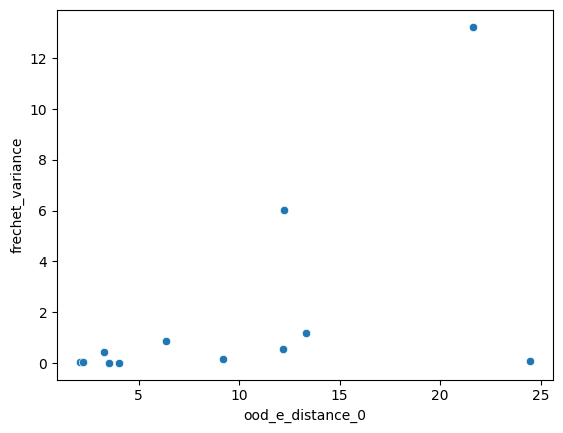

In [89]:
sns.scatterplot(df[["ood_e_distance_0", "frechet_variance"]], x="ood_e_distance_0", y="frechet_variance")

<Axes: xlabel='mean_ood_e_distance', ylabel='frechet_variance'>

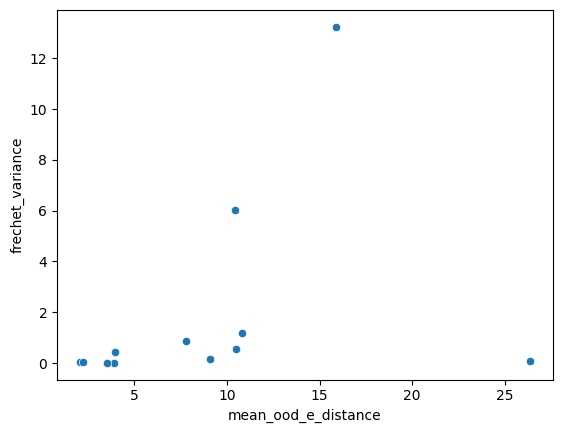

In [91]:
sns.scatterplot(df[["mean_ood_e_distance", "frechet_variance"]], x="mean_ood_e_distance", y="frechet_variance")

In [83]:
df.head()

,ood_e_distance_0,decoded_ood_r_squared_0,ood_e_distance_1,decoded_ood_r_squared_1,ood_e_distance_2,decoded_ood_r_squared_2,ood_e_distance_3,decoded_ood_r_squared_3,ood_e_distance_4,decoded_ood_r_squared_4,...,var_mean_gex_HSPC,var_mean_deg_gex_HSPC,var_mean_gex_Platelet,var_mean_deg_gex_Platelet,mean_var_mean_gex_per_cell_type,mean_var_mean_deg_gex_per_cell_type,frechet_variance_other,var_mean_gex_other,var_mean_deg_gex_other,neg_mean_deg_r_sq_per_cell_type
Donor10_OX40L,6.349233,0.983400,5.950117,0.983958,9.700186,0.979335,9.627871,0.979418,6.596342,0.983114,...,0.000000,0.000000,0.000423,0.002654,0.002738,0.027847,NaN,NaN,NaN,-0.806733
Donor11_OX40L,21.614715,0.952222,35.872900,0.928994,7.758931,0.974872,7.705519,0.974940,22.221145,0.951130,...,0.011373,0.040354,NaN,NaN,0.007637,0.029667,42903.582673,0.028723,0.116759,-0.777709
Donor12_OX40L,3.293985,0.980145,3.393247,0.979558,4.640966,0.977492,4.505762,0.977861,3.370295,0.979934,...,0.037871,0.180092,0.000075,0.001254,0.006983,0.047798,3399.352646,0.004417,0.037878,-0.796987
Donor1_OX40L,12.199255,0.977946,17.273002,0.971398,7.553855,0.983910,7.521734,0.983914,12.552731,0.977543,...,0.005969,0.042233,NaN,NaN,0.002777,0.021319,36474.856383,0.025244,0.161148,-0.764360
Donor2_OX40L,4.029278,0.981134,4.769887,0.979750,3.548957,0.982014,3.478552,0.982192,4.132760,0.981006,...,0.025696,0.093221,NaN,NaN,0.002995,0.012154,302.804586,0.001752,0.008903,-0.824513
